## **Create a project using logistic regression with tensor**

In [1]:
# Import TensorFlow, NumPy, and Matplotlib for model building and visualization.
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Prepare marks and pass/fail labels for the binary classification task.
# Marks out of 100
marks = tf.constant(
    [18, 25, 30, 33, 36, 38, 42, 45, 49, 52, 55, 58, 62, 66, 70, 74, 78, 82, 90],
    dtype=tf.float32
)

marks = tf.reshape(marks, (-1, 1))

# Result: 0 = Fail, 1 = Pass (Pass assumed around 40+ but with slight noise)
result = tf.constant(
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    dtype=tf.float32
)

result = tf.reshape(result, (-1, 1))

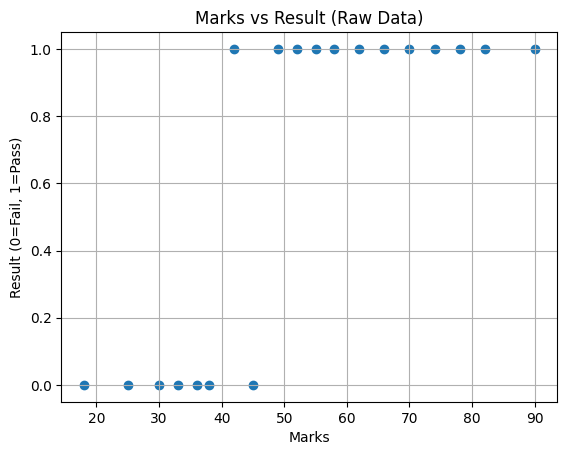

In [3]:
# Visualize the raw relationship between marks and result labels.
plt.scatter(marks.numpy(), result.numpy())
plt.xlabel("Marks")
plt.ylabel("Result (0=Fail, 1=Pass)")
plt.title("Marks vs Result (Raw Data)")
plt.grid(True)
plt.show()

In [4]:
# Define trainable logistic regression parameters and helper functions.
W = tf.Variable(tf.zeros((1, 1), dtype=tf.float32))
b = tf.Variable(0.0, dtype=tf.float32)

def predict_proba(X):
    logits = tf.matmul(X, W) + b
    return tf.sigmoid(logits)

def loss_fn(y_true, y_pred):
    # Binary Cross Entropy (safe)
    eps = 1e-7
    y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

In [5]:
# Train the logistic regression model using gradient descent.
lr = 0.05
epochs = 1200

for epoch in range(1, epochs + 1):
    with tf.GradientTape() as tape:
        y_pred = predict_proba(marks)
        loss = loss_fn(result, y_pred)

    dW, db = tape.gradient(loss, [W, b])
    W.assign_sub(lr * dW)
    b.assign_sub(lr * db)

    if epoch % 200 == 0:
        print(f"Epoch {epoch:>4} | Loss={loss.numpy():.4f} | W={W.numpy()[0][0]:.4f} | b={b.numpy():.4f}")

Epoch  200 | Loss=5.8735 | W=1.8862 | b=-0.0041
Epoch  400 | Loss=5.8735 | W=1.8862 | b=-0.0041
Epoch  600 | Loss=5.8735 | W=1.8862 | b=-0.0041
Epoch  800 | Loss=5.8735 | W=1.8862 | b=-0.0041
Epoch 1000 | Loss=5.8735 | W=1.8862 | b=-0.0041
Epoch 1200 | Loss=5.8735 | W=1.8862 | b=-0.0041


In [6]:
# Test the trained model on new marks and print pass/fail predictions.
new_marks = tf.constant([[35.0], [41.0], [49.0], [60.0], [75.0]], dtype=tf.float32)

proba = predict_proba(new_marks).numpy().flatten()
pred = (proba >= 0.5).astype(int)

print("\nMarks | Prob(Pass) | Prediction")
for m, p, pr in zip(new_marks.numpy().flatten(), proba, pred):
    print(f"{m:>5.1f} |   {p:>6.3f}   | {'PASS' if pr==1 else 'FAIL'}")


Marks | Prob(Pass) | Prediction
 35.0 |    1.000   | PASS
 41.0 |    1.000   | PASS
 49.0 |    1.000   | PASS
 60.0 |    1.000   | PASS
 75.0 |    1.000   | PASS


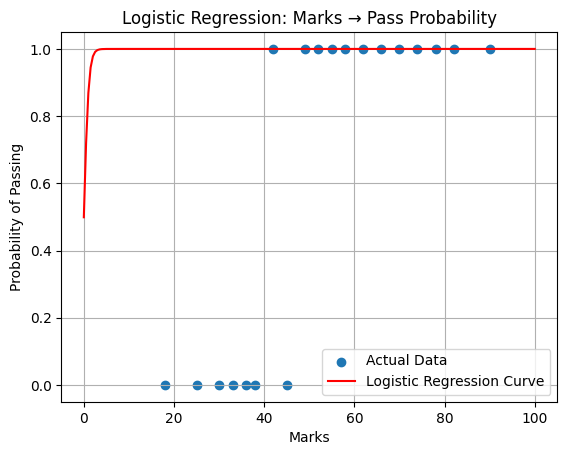

In [7]:
# Plot the learned sigmoid curve against the original training samples.
x_line = np.linspace(0, 100, 200).reshape(-1, 1).astype(np.float32)
y_line = predict_proba(tf.constant(x_line)).numpy()

plt.scatter(marks.numpy(), result.numpy(), label="Actual Data")
plt.plot(x_line, y_line, color="red", label="Logistic Regression Curve")

plt.xlabel("Marks")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression: Marks → Pass Probability")
plt.legend()
plt.grid(True)
plt.show()